# EDA RFM: từ giao dịch đến phân khúc khách hàng

Đọc Parquet đã có để phân tích giao dịch curated và kết quả RFM theo khách hàng. Notebook không chạy Spark, không huấn luyện lại K-Means và không ghi dữ liệu.

**A: cấu hình/nguồn → B: chất lượng giao dịch → C: khách hàng RFM → D: phân phối/điểm → E: profile cụm → F: diễn giải → G: kiểm chứng.**

Chạy **Restart Kernel → Run All**. Hướng dẫn: [EDA_RFM_Guide_VI.md](EDA_RFM_Guide_VI.md). So sánh k: [comparison_revised.ipynb](comparison_revised.ipynb).

## A. Cấu hình và đọc giao dịch curated

Kernel cần pandas, pyarrow, numpy, matplotlib, seaborn. Nếu thiếu, chạy `%pip install pandas pyarrow numpy matplotlib seaborn`, sau đó restart kernel.

`RFM.parquet` là **dòng giao dịch**; `rfm_daily` là **khách hàng**. Các đường dẫn dùng đầu ra legacy/local. Để đọc đầu ra versioned của DAG, đổi đường dẫn theo manifest đã publish; không tự chọn phiên bản mới nhất.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PROJECT_ROOT_OVERRIDE = None
RUN_DATE = "2011-12-10"
RANDOM_STATE = 42
cwd = Path.cwd().resolve()
PROJECT_ROOT = (Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()
                if PROJECT_ROOT_OVERRIDE else next(
                    (p for p in (cwd, *cwd.parents)
                     if (p / "scripts" / "pyspark_clean.py").is_file()), None))
if PROJECT_ROOT is None:
    raise FileNotFoundError("Check the configured repository/data path.")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)
metrics = ["Recency", "Frequency", "Monetary"]

PARQUET_PATH = PROJECT_ROOT / "data/curated/RFM.parquet"
RFM_OUTPUT_PATH = PROJECT_ROOT / "data/analytics/rfm_daily" / f"run_date={RUN_DATE}"
print("Input/output validation; see the displayed tables and configured paths.")
print("Input/output validation; see the displayed tables and configured paths.")

Input/output validation; see the displayed tables and configured paths.
Input/output validation; see the displayed tables and configured paths.


In [2]:
if not PARQUET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {PARQUET_PATH}. "
        "Set PARQUET_PATH to your existing RFM.parquet file or directory."
    )

df = pd.read_parquet(PARQUET_PATH, engine="pyarrow")
if df.shape[1] == 0:
    raise ValueError(
        f"No Parquet columns found in {PARQUET_PATH}. "
        "Copy the complete Spark Parquet output (including part-*.parquet files) here, "
        "or set PARQUET_PATH to an existing dataset."
    )
print(f"Rows: {len(df):,} | Columns: {len(df.columns)}")
display(df.head(10))

Rows: 391,057 | Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536396,21068,VINTAGE BILLBOARD LOVE/HATE MUG,6,2010-12-01 10:51:00,1.06,17850,United Kingdom
1,536401,20820,SILVER LOOKING MIRROR,3,2010-12-01 11:21:00,4.95,15862,United Kingdom
2,536464,22810,SET OF 6 T-LIGHTS SNOWMEN,1,2010-12-01 12:23:00,2.95,17968,United Kingdom
3,536542,21928,JUMBO BAG SCANDINAVIAN PAISLEY,20,2010-12-01 14:11:00,1.95,16456,United Kingdom
4,536557,22694,WICKER STAR,2,2010-12-01 14:41:00,2.10,17841,United Kingdom
5,536595,20679,EDWARDIAN PARASOL RED,1,2010-12-01 17:24:00,5.95,13576,United Kingdom
6,536611,84031A,CHARLIE+LOLA RED HOT WATER BOTTLE,3,2010-12-02 09:43:00,4.65,15752,United Kingdom
7,536618,20975,12 PENCILS SMALL TUBE RED RETROSPOT,24,2010-12-02 10:17:00,0.65,17017,United Kingdom
8,536623,22023,EMPIRE BIRTHDAY CARD,12,2010-12-02 10:39:00,0.42,15601,United Kingdom
9,536792,22558,CLOTHES PEGS RETROSPOT PACK 24,24,2010-12-02 15:28:00,1.25,15061,United Kingdom


## B. Chất lượng và bối cảnh giao dịch

Cleaning hiện tại loại trùng, thiếu giá trị, hóa đơn C, Quantity/UnitPrice không dương và các dòng phí đã định nghĩa. Kiểm tra dữ liệu đang đọc vì đầu ra cũ có thể chưa tuân thủ hợp đồng mới.

Null/trùng là kiểm tra toàn tập; head và top giá là mẫu xem xét. Country/Description đếm **dòng**, không đếm khách hay hóa đơn.

In [3]:
df.info()
display(pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100),
    "unique_values": df.nunique(),
}))
print(f"Duplicate rows: {df.duplicated().sum():,}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391057 entries, 0 to 391056
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    391057 non-null  object        
 1   StockCode    391057 non-null  object        
 2   Description  391057 non-null  object        
 3   Quantity     391057 non-null  int32         
 4   InvoiceDate  391057 non-null  datetime64[ns]
 5   UnitPrice    391057 non-null  float64       
 6   CustomerID   391057 non-null  object        
 7   Country      391057 non-null  object        
dtypes: datetime64[ns](1), float64(1), int32(1), object(5)
memory usage: 22.4+ MB


,dtype,missing_count,missing_percent,unique_values
InvoiceNo,object,0,0.0,18402
StockCode,object,0,0.0,3657
Description,object,0,0.0,3869
Quantity,int32,0,0.0,299
InvoiceDate,datetime64[ns],0,0.0,17166
UnitPrice,float64,0,0.0,353
CustomerID,object,0,0.0,4334
Country,object,0,0.0,37


Duplicate rows: 0


In [4]:
checks = {}
if "InvoiceNo" in df:
    checks["Cancellation rows (InvoiceNo starts with C)"] = (
        df["InvoiceNo"].astype("string").str.upper().str.startswith("C").sum()
    )
for column in ("Quantity", "UnitPrice"):
    if column in df:
        values = pd.to_numeric(df[column], errors="coerce")
        checks[f"{column}: negative"] = values.lt(0).sum()
        checks[f"{column}: zero"] = values.eq(0).sum()
        checks[f"{column}: non-null values that are not numeric"] = (
            df[column].notna() & values.isna()
        ).sum()
display(pd.Series(checks, name="row_count").to_frame())

,row_count
Cancellation rows (InvoiceNo starts with C),0
Quantity: negative,0
Quantity: zero,0
Quantity: non-null values that are not numeric,0
UnitPrice: negative,0
UnitPrice: zero,0
UnitPrice: non-null values that are not numeric,0


In [5]:
required_transactions = {"CustomerID", "InvoiceNo", "InvoiceDate", "Quantity", "UnitPrice"}
assert required_transactions.issubset(df.columns)
transaction_summary = pd.Series({
    "transaction_rows": len(df),
    "customers": df["CustomerID"].nunique(),
    "invoices": df["InvoiceNo"].nunique(),
    "first_date": df["InvoiceDate"].min(),
    "last_date": df["InvoiceDate"].max(),
})
display(transaction_summary.to_frame("value"))
display(df.describe(include="all").T)
display(df.sort_values("UnitPrice", ascending=False).head(20))

,value
transaction_rows,391057
customers,4334
invoices,18402
first_date,2010-12-01 08:26:00
last_date,2011-12-09 12:50:00


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,391057,18402,576339,541,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,391057,3657,85123A,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,391057,3869,WHITE HANGING HEART T-LIGHT HOLDER,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,391057.0,NaN,NaN,NaN,13.148188,1.0,2.0,6.0,12.0,80995.0,180.829232
InvoiceDate,391057,NaN,NaN,NaN,2011-07-10 19:10:14.650754048,2010-12-01 08:26:00,2011-04-07 11:12:00,2011-07-31 12:02:00,2011-10-20 12:53:00,2011-12-09 12:50:00,NaN
UnitPrice,391057.0,NaN,NaN,NaN,2.871719,0.04,1.25,1.95,3.75,649.5,4.281515
CustomerID,391057,4334,17841,7667,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,391057,37,United Kingdom,348781,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
363066,556446,22502,PICNIC BASKET WICKER 60 PIECES,1,2011-06-10 15:33:00,649.5,15098,United Kingdom
232047,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.5,15098,United Kingdom
349150,540647,22655,VINTAGE RED KITCHEN CABINET,1,2011-01-10 14:57:00,295.0,17406,United Kingdom
31450,536835,22655,VINTAGE RED KITCHEN CABINET,1,2010-12-02 18:06:00,295.0,13145,United Kingdom
190353,539080,22655,VINTAGE RED KITCHEN CABINET,1,2010-12-16 08:41:00,295.0,16607,United Kingdom
354699,547814,22656,VINTAGE BLUE KITCHEN CABINET,1,2011-03-25 14:19:00,295.0,13452,United Kingdom
322957,551393,22656,VINTAGE BLUE KITCHEN CABINET,1,2011-04-28 12:22:00,295.0,14973,United Kingdom
129571,543253,22655,VINTAGE RED KITCHEN CABINET,1,2011-02-04 15:32:00,295.0,14842,United Kingdom
324737,554836,22655,VINTAGE RED KITCHEN CABINET,1,2011-05-26 16:25:00,295.0,13015,United Kingdom
354275,546480,22656,VINTAGE BLUE KITCHEN CABINET,1,2011-03-14 11:38:00,295.0,13452,United Kingdom


In [6]:
for column in ("Country", "Description"):
    if column in df:
        print(f"Top 15: {column}")
        display(df[column].value_counts(dropna=False).head(15).to_frame("rows"))

Top 15: Country


,rows
Country,
United Kingdom,348781
Germany,8643
France,8018
EIRE,7125
Spain,2417
Netherlands,2322
Belgium,1935
Switzerland,1810
Portugal,1416


Top 15: Description


,rows
Description,
WHITE HANGING HEART T-LIGHT HOLDER,2016
REGENCY CAKESTAND 3 TIER,1713
JUMBO BAG RED RETROSPOT,1615
ASSORTED COLOUR BIRD ORNAMENT,1395
PARTY BUNTING,1389
LUNCH BAG RED RETROSPOT,1303
SET OF 3 CAKE TINS PANTRY DESIGN,1152
LUNCH BAG BLACK SKULL.,1078
PACK OF 72 RETROSPOT CAKE CASES,1050


### B1. Đối soát một khách hàng

Đổi CUSTOMER_ID để xem dòng và số hóa đơn duy nhất. Frequency trong RFM chỉ tính lịch sử **trước RUN_DATE**; curated có thể chứa cả giao dịch từ ngày chốt trở đi.

In [7]:
CUSTOMER_ID = "12748"
customer_rows = df.loc[df["CustomerID"].astype("string").eq(CUSTOMER_ID)]
display(customer_rows)
print("Distinct curated invoices:", customer_rows["InvoiceNo"].nunique())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
32,537136,21980,PACK OF 12 RED RETROSPOT TISSUES,12,2010-12-05 12:42:00,0.29,12748,United Kingdom
34,537155,21427,SKULLS STORAGE BOX SMALL,2,2010-12-05 13:05:00,2.10,12748,United Kingdom
45,537429,22419,LIPSTICK PEN RED,2,2010-12-06 15:54:00,0.42,12748,United Kingdom
92,539181,47567B,TEA TIME KITCHEN APRON,1,2010-12-16 11:51:00,5.95,12748,United Kingdom
310,537225,20771,CHRYSANTHEMUM JOURNAL,2,2010-12-05 16:41:00,2.55,12748,United Kingdom
...,...,...,...,...,...,...,...,...
390958,579430,23310,BUBBLEGUM RING ASSORTED,30,2011-11-29 13:06:00,0.42,12748,United Kingdom
390967,579520,22340,NOEL GARLAND PAINTED ZINC,2,2011-11-29 18:14:00,0.39,12748,United Kingdom
390968,579520,47563A,RETRO LONGBOARD IRONING BOARD COVER,1,2011-11-29 18:14:00,1.25,12748,United Kingdom
390976,580048,21389,IVORY HANGING DECORATION BIRD,2,2011-12-01 12:53:00,0.85,12748,United Kingdom


Distinct curated invoices: 206


## C. Đọc và kiểm tra kết quả RFM theo khách hàng

Recency là số ngày từ lần mua cuối đến ngày chốt; Frequency là số hóa đơn khác nhau; Monetary là tổng giá trị giao dịch hợp lệ trong lịch sử trước ngày chốt. Mỗi dòng phải là một CustomerID duy nhất.

Monetary chuyển sang float trong bản sao pandas để thống kê/vẽ; notebook không thay thế phép tính decimal của Spark.

In [8]:
if not RFM_OUTPUT_PATH.exists():
    raise FileNotFoundError("Check the configured repository/data path.")
rfm = pd.read_parquet(RFM_OUTPUT_PATH, engine="pyarrow").copy()
required = {"CustomerID", "Cluster", "R_score", "F_score", "M_score", "RFM_score", *metrics}
assert required.issubset(rfm.columns), "Missing required columns"
assert not rfm.empty and rfm["CustomerID"].notna().all() and rfm["CustomerID"].is_unique
for metric in metrics:
    rfm[metric] = pd.to_numeric(rfm[metric], errors="raise")
values = rfm[metrics].to_numpy(dtype=float)
assert np.isfinite(values).all()
assert rfm["Recency"].ge(1).all() and rfm["Frequency"].ge(1).all() and rfm["Monetary"].ge(0).all()
assert rfm["Cluster"].notna().all()
assert pd.api.types.is_integer_dtype(rfm["Cluster"])
k = rfm["Cluster"].nunique()
assert k in (2, 3, 4), "EDA labels support only k=2,3,4."
assert set(rfm["Cluster"]) == set(range(k))
for score in ["R_score", "F_score", "M_score"]:
    assert rfm[score].isin([1, 2, 3, 4, 5]).all()
if "run_date" in rfm:
    assert pd.to_datetime(rfm["run_date"]).dt.strftime("%Y-%m-%d").eq(RUN_DATE).all()
if "LastPurchaseDate" in rfm:
    last = pd.to_datetime(rfm["LastPurchaseDate"])
    assert last.notna().all() and last.lt(pd.Timestamp(RUN_DATE)).all()
    assert (pd.Timestamp(RUN_DATE) - last.dt.normalize()).dt.days.eq(rfm["Recency"]).all()
print(f"Run date: {RUN_DATE} | Customers: {len(rfm):,} | k={k}")
display(rfm.head(20))
display(rfm.sample(n=min(20, len(rfm)), random_state=RANDOM_STATE))
display(rfm[metrics].describe())
display(rfm.loc[rfm["CustomerID"].astype("string").eq("14646")])
display(rfm.sort_values("Monetary", ascending=False).head(20))

Run date: 2011-12-10 | Customers: 4,334 | k=4


,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Cluster
0,16738,2011-02-15 09:46:00,298,1,3.75,1,1,1,111,2
1,16454,2011-10-06 16:57:00,65,1,5.90,3,1,1,311,2
2,14792,2011-10-07 09:19:00,64,1,6.20,3,1,1,311,2
3,17956,2011-04-04 13:47:00,250,1,12.75,1,1,1,111,2
4,16878,2011-09-16 17:39:00,85,1,13.30,2,1,1,211,2
5,17763,2011-03-21 14:25:00,264,1,15.00,1,1,1,111,2
6,13307,2011-08-11 17:14:00,121,1,15.00,2,1,1,211,2
7,16093,2011-08-25 11:09:00,107,1,17.00,2,1,1,211,2
8,17986,2011-10-14 14:22:00,57,1,20.80,3,1,1,311,2
9,16953,2011-11-09 15:54:00,31,1,20.80,4,1,1,411,2


,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Cluster
2439,15533,2011-11-20 15:35:00,20,3,807.57,4,3,3,433,3
1213,14987,2011-11-24 09:59:00,16,2,326.40,4,2,2,422,3
2659,17100,2011-11-21 16:36:00,19,2,971.74,4,2,4,424,3
17,15744,2011-09-23 09:52:00,78,1,34.80,2,1,1,211,2
3802,13631,2011-09-01 09:57:00,100,11,3070.42,2,5,5,255,1
3734,15993,2011-12-01 10:45:00,9,7,2768.97,5,5,5,555,1
134,13551,2011-01-24 14:46:00,320,1,91.80,1,1,1,111,2
1057,17793,2011-11-14 14:24:00,26,1,300.34,4,1,2,412,2
869,18072,2011-06-07 10:44:00,186,1,247.44,1,1,2,112,2
3662,14334,2011-11-23 10:01:00,17,8,2552.21,4,5,5,455,1


,Recency,Frequency,Monetary
count,4334.000000,4334.000000,4334.000000
mean,93.226581,4.245962,2015.672044
std,100.175327,7.634989,8903.630660
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,304.240000
50%,51.000000,2.000000,661.420000
75%,143.000000,5.000000,1631.622500
max,374.000000,206.000000,279138.020000


,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Cluster
4333,14646,2011-12-08 12:12:00,2,72,279138.02,5,5,5,555,1


,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Cluster
4333,14646,2011-12-08 12:12:00,2,72,279138.02,5,5,5,555,1
4332,18102,2011-12-09 11:50:00,1,60,259657.30,5,5,5,555,1
4331,17450,2011-12-01 13:29:00,9,46,194390.79,5,5,5,555,1
4330,16446,2011-12-09 09:15:00,1,2,168472.50,5,2,5,525,1
4329,14911,2011-12-08 15:54:00,2,198,136154.33,5,5,5,555,1
4328,12415,2011-11-15 14:22:00,25,20,124564.53,4,5,5,455,1
4327,14156,2011-11-30 10:54:00,10,54,116560.08,5,5,5,555,1
4326,17511,2011-12-07 10:12:00,3,31,91062.38,5,5,5,555,1
4325,12346,2011-01-18 10:01:00,326,1,77183.60,1,1,5,115,0
4324,16029,2011-11-01 10:27:00,39,62,72708.09,3,5,5,355,1


## D. Phân phối RFM và điểm tương đối

So sánh thang gốc và log1p để thấy độ lệch. Job K-Means dùng log1p rồi StandardScaler trên R/F/M, không dùng ba score làm feature.

Score 5 là phía thuận lợi hơn trong cohort: Recency thấp, Frequency/Monetary cao. percent_rank giữ ties nên mỗi mức không nhất thiết chứa 20% khách; metric hằng nhận score 1.

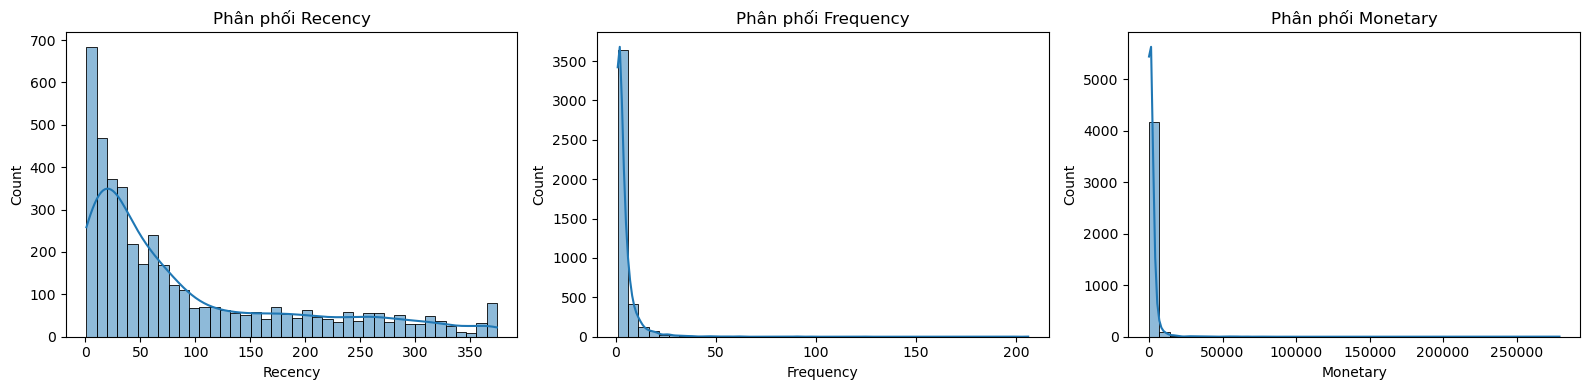

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.histplot(rfm[col], bins=40, ax=ax, kde=True)
    ax.set_title(f"Phân phối {col}")
plt.tight_layout()
plt.show()

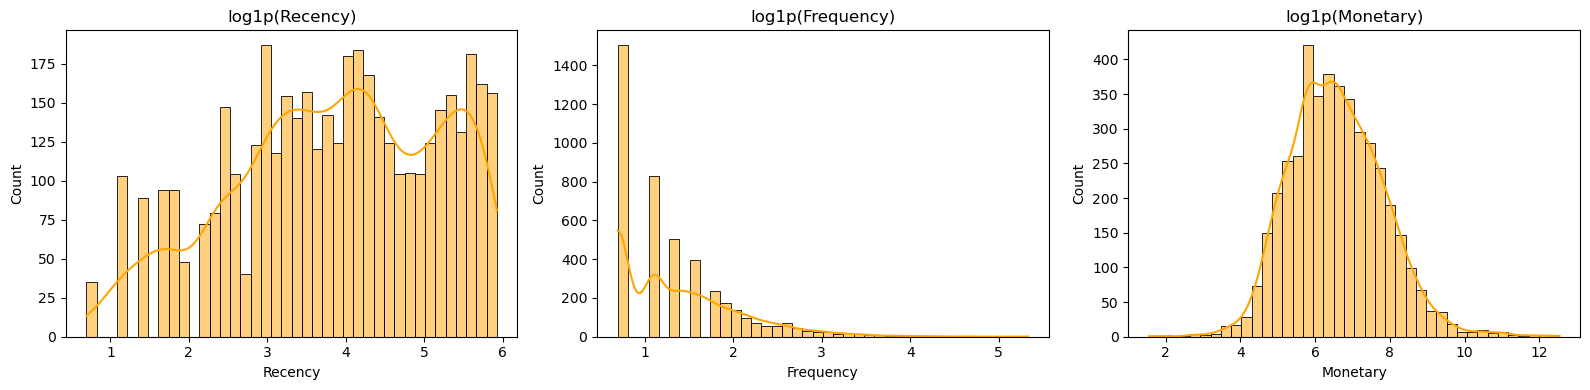

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.histplot(np.log1p(rfm[col]), bins=40, ax=ax, kde=True, color="orange")
    ax.set_title(f"log1p({col})")
plt.tight_layout()
plt.show()

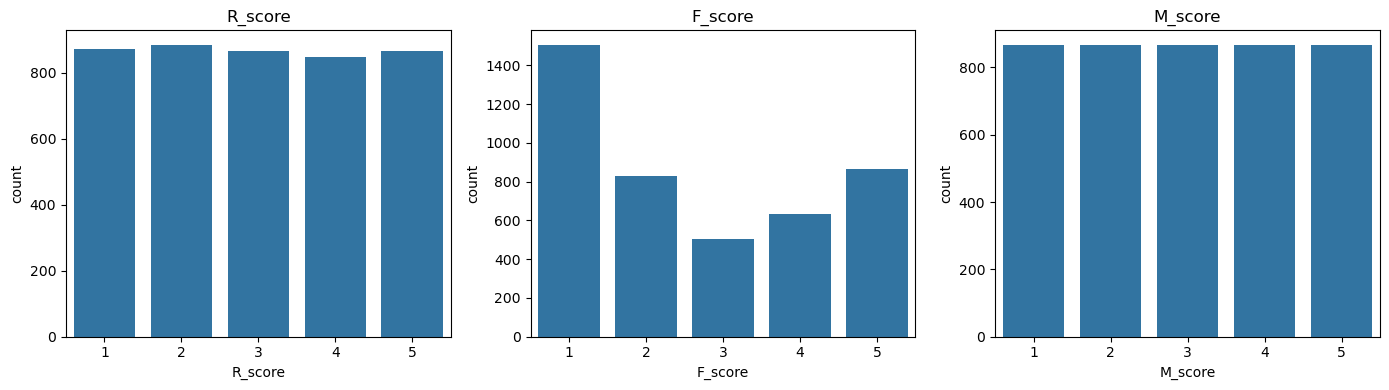

Top 10 mã RFM_score phổ biến nhất:


RFM_score
555    348
111    332
112    209
455    172
211    148
311    130
212    112
312    104
223     97
411     86
Name: count, dtype: int64

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["R_score", "F_score", "M_score"]):
    sns.countplot(x=rfm[col], ax=ax, order=[1, 2, 3, 4, 5])
    ax.set_title(col)
plt.tight_layout()
plt.show()

print("Top 10 mã RFM_score phổ biến nhất:")
rfm["RFM_score"].value_counts().head(10)

## E. Quy mô và profile cụm

Cluster chỉ là mã mô hình. Đọc median/quartile cùng mean vì khách chi rất lớn có thể kéo trung bình. Tỷ lệ khách dùng tổng khách làm mẫu số; tỷ trọng Monetary dùng tổng Monetary của snapshot.

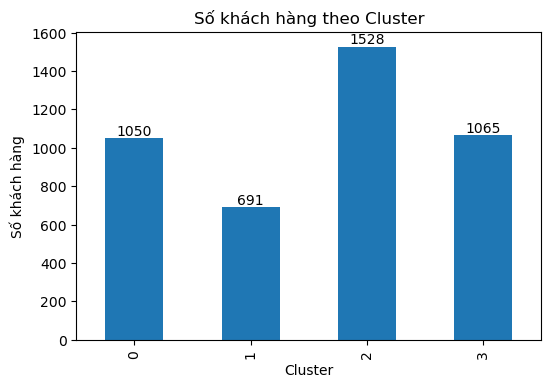

Cluster
0    1050
1     691
2    1528
3    1065
Name: count, dtype: int64

In [12]:
cluster_sizes = rfm["Cluster"].value_counts().sort_index()
ax = cluster_sizes.plot(kind="bar", figsize=(6, 4))
ax.set_title("Số khách hàng theo Cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Số khách hàng")
for i, v in enumerate(cluster_sizes):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.show()

cluster_sizes

In [13]:
cluster_profile = rfm.groupby("Cluster").agg(
    n_customers=("CustomerID", "size"),
    recency_mean=("Recency", "mean"), recency_median=("Recency", "median"),
    frequency_mean=("Frequency", "mean"), frequency_median=("Frequency", "median"),
    monetary_mean=("Monetary", "mean"), monetary_median=("Monetary", "median"),
    monetary_total=("Monetary", "sum"),
    one_purchase_pct=("Frequency", lambda s: s.eq(1).mean() * 100),
)
for metric in metrics:
    grouped = rfm.groupby("Cluster")[metric]
    cluster_profile[f"{metric}_q1"] = grouped.quantile(0.25)
    cluster_profile[f"{metric}_q3"] = grouped.quantile(0.75)
cluster_profile["customer_pct"] = cluster_profile["n_customers"] / len(rfm) * 100
cluster_profile["monetary_pct"] = cluster_profile["monetary_total"] / rfm["Monetary"].sum() * 100
assert cluster_profile["n_customers"].sum() == len(rfm)
display(cluster_profile.round(2))

,n_customers,recency_mean,recency_median,frequency_mean,frequency_median,monetary_mean,monetary_median,monetary_total,one_purchase_pct,Recency_q1,Recency_q3,Frequency_q1,Frequency_q3,Monetary_q1,Monetary_q3,customer_pct,monetary_pct
Cluster,,,,,,,,,,,,,,,,,
0,1050,111.16,82.5,3.18,3.0,1493.63,1018.60,1568308.47,10.57,59.0,144.00,2.0,4.0,680.59,1647.42,24.23,17.95
1,691,16.54,10.0,14.13,10.0,8284.24,3901.81,5724410.56,0.00,4.0,23.00,8.0,15.0,2561.32,6415.44,15.94,65.53
2,1528,168.56,159.5,1.19,1.0,262.89,236.03,401688.35,83.51,64.0,262.25,1.0,1.0,149.43,348.84,35.26,4.60
3,1065,17.22,17.0,3.27,3.0,977.95,812.68,1041515.26,11.08,9.0,25.00,2.0,4.0,478.78,1308.61,24.57,11.92


### E1. Heatmap và độ phân tán

Xanh thể hiện phía thuận lợi hơn: Recency thấp hoặc Frequency/Monetary cao. Màu chuẩn hóa **giữa trung bình các cụm**; số chú thích vẫn là trung bình gốc. Đây không phải feature scaler của K-Means. Cột không phân tán được tô trung tính.

Boxplot ẩn điểm ngoại lệ để nhìn hộp rõ, không loại khách khỏi thống kê. Scatter giữ toàn bộ khách.

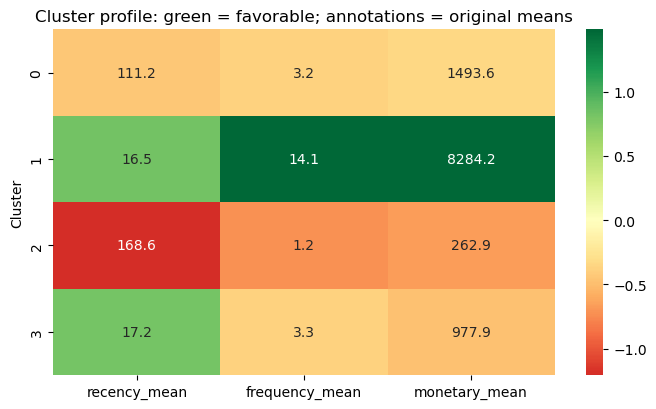

In [14]:
mean_columns = ["recency_mean", "frequency_mean", "monetary_mean"]
mean_profile = cluster_profile[mean_columns]
z = ((mean_profile - mean_profile.mean()) / mean_profile.std().replace(0, np.nan)).fillna(0)
favorable = z.mul(pd.Series({"recency_mean": -1, "frequency_mean": 1, "monetary_mean": 1}))
assert np.allclose(favorable["recency_mean"], -z["recency_mean"])
assert np.allclose(favorable[["frequency_mean", "monetary_mean"]], z[["frequency_mean", "monetary_mean"]])
plt.figure(figsize=(7, k * 0.8 + 1))
sns.heatmap(favorable, annot=mean_profile, fmt=".1f", cmap="RdYlGn", center=0)
plt.title("Cluster profile: green = favorable; annotations = original means")
plt.tight_layout()
plt.show()

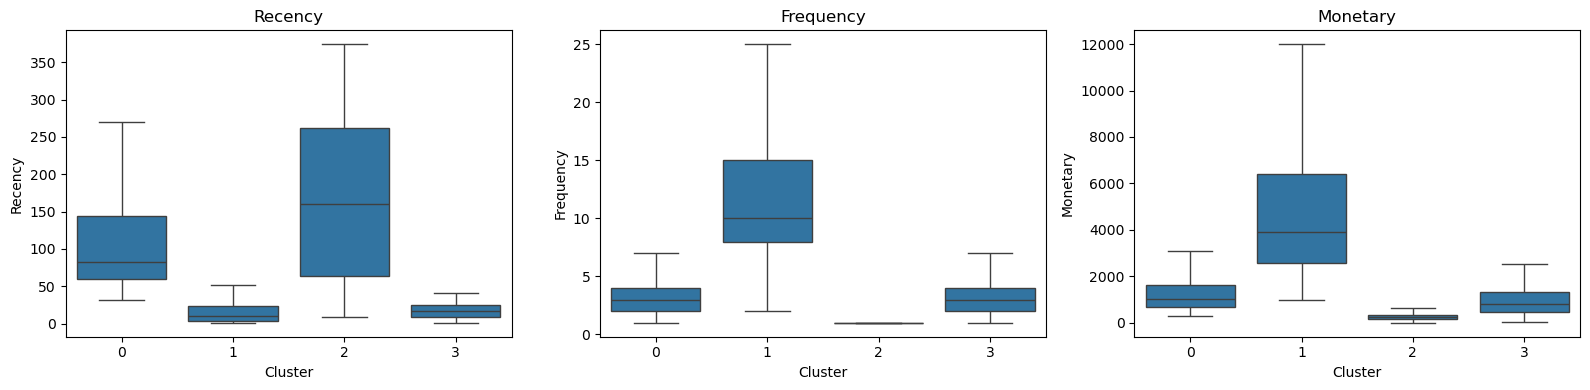

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.boxplot(x="Cluster", y=col, data=rfm, ax=ax, showfliers=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()

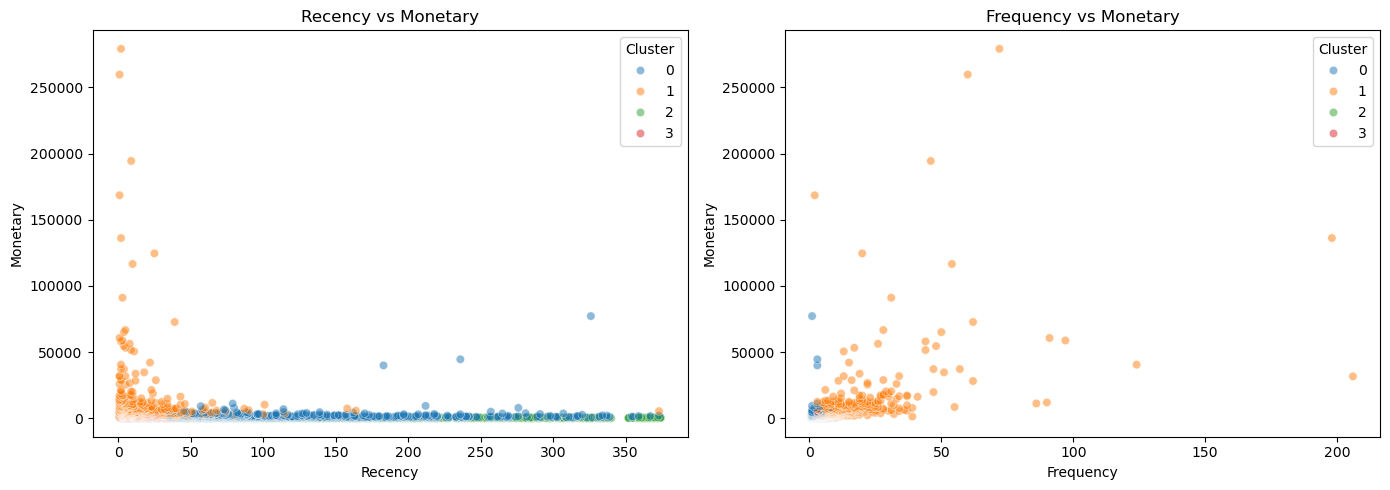

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (x, y) in zip(axes, [("Recency", "Monetary"), ("Frequency", "Monetary")]):
    sns.scatterplot(x=x, y=y, hue="Cluster", data=rfm, palette="tab10", alpha=0.5, ax=ax)
    ax.set_title(f"{x} vs {y}")
plt.tight_layout()
plt.show()

## F. Nhãn diễn giải theo profile

Xếp Monetary median tăng dần, phá hòa bằng Frequency median tăng dần rồi Recency median giảm dần. Hai đầu là Lower-value/Higher-value. k=3 thêm Intermediate; k=4 tách hai cụm giữa theo Recency median thành Recent Moderate/Less-recent Moderate.

Nhãn tương đối trong snapshot, không khẳng định khách mới, VIP hay đã rời bỏ. Profile hòa thì dừng để xem lại. Giữ Segment của pipeline nếu có, thêm EDA_Segment riêng.

In [17]:
def semantic_mapping(profile, k):
    keys = ['monetary_median', 'frequency_median', 'recency_median']
    if profile.duplicated(keys).any():
        raise ValueError('Profile hòa: cần xem lại quy tắc đặt nhãn.')
    ranked = profile.sort_values(keys, ascending=[True, True, False])
    mapping = {ranked.index[0]: 'Lower-value', ranked.index[-1]: 'Higher-value'}
    if k == 3:
        mapping[ranked.index[1]] = 'Intermediate'
    elif k == 4:
        moderate = ranked.iloc[1:-1].sort_values('recency_median')
        if moderate['recency_median'].nunique() != 2:
            raise ValueError('Recency median hòa: không thể đặt nhãn recent/less-recent.')
        mapping.update(dict(zip(moderate.index, ['Recent Moderate', 'Less-recent Moderate'])))
    return mapping


cluster_names = semantic_mapping(cluster_profile, k)
rfm["EDA_Segment"] = rfm["Cluster"].map(cluster_names)
assert rfm["EDA_Segment"].notna().all()
display(cluster_profile.assign(EDA_Segment=cluster_profile.index.map(cluster_names)).round(2))
display(rfm[["CustomerID", "Cluster", "EDA_Segment", *metrics]].sample(
    n=min(10, len(rfm)), random_state=RANDOM_STATE))

,n_customers,recency_mean,recency_median,frequency_mean,frequency_median,monetary_mean,monetary_median,monetary_total,one_purchase_pct,Recency_q1,Recency_q3,Frequency_q1,Frequency_q3,Monetary_q1,Monetary_q3,customer_pct,monetary_pct,EDA_Segment
Cluster,,,,,,,,,,,,,,,,,,
0,1050,111.16,82.5,3.18,3.0,1493.63,1018.60,1568308.47,10.57,59.0,144.00,2.0,4.0,680.59,1647.42,24.23,17.95,Less-recent Moderate
1,691,16.54,10.0,14.13,10.0,8284.24,3901.81,5724410.56,0.00,4.0,23.00,8.0,15.0,2561.32,6415.44,15.94,65.53,Higher-value
2,1528,168.56,159.5,1.19,1.0,262.89,236.03,401688.35,83.51,64.0,262.25,1.0,1.0,149.43,348.84,35.26,4.60,Lower-value
3,1065,17.22,17.0,3.27,3.0,977.95,812.68,1041515.26,11.08,9.0,25.00,2.0,4.0,478.78,1308.61,24.57,11.92,Recent Moderate


,CustomerID,Cluster,EDA_Segment,Recency,Frequency,Monetary
2439,15533,3,Recent Moderate,20,3,807.57
1213,14987,3,Recent Moderate,16,2,326.40
2659,17100,3,Recent Moderate,19,2,971.74
17,15744,2,Lower-value,78,1,34.80
3802,13631,1,Higher-value,100,11,3070.42
3734,15993,1,Higher-value,9,7,2768.97
134,13551,2,Lower-value,320,1,91.80
1057,17793,2,Lower-value,26,1,300.34
869,18072,2,Lower-value,186,1,247.44
3662,14334,1,Higher-value,17,8,2552.21


## G. Kiểm chứng và bước tiếp theo

Assertion kiểm tra khóa khách, metric hữu hạn/hợp lệ, score, mã cụm, ngày chốt nếu có và tổng số khách trong profile. Đọc bảng tính động trước khi đưa số vào báo cáo.

Chọn k bằng [comparison_revised.ipynb](comparison_revised.ipynb). Chưa kiểm chứng ổn định qua seed/ngày hoặc hiệu quả chiến dịch. Có thể thêm cell khám phá bên dưới; tạo bản sao trước khi biến đổi.